<a href="https://colab.research.google.com/github/kishita21/MLDL/blob/main/EXP6/EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


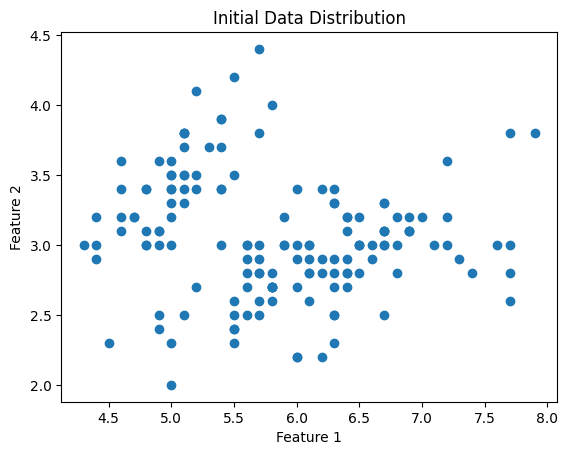

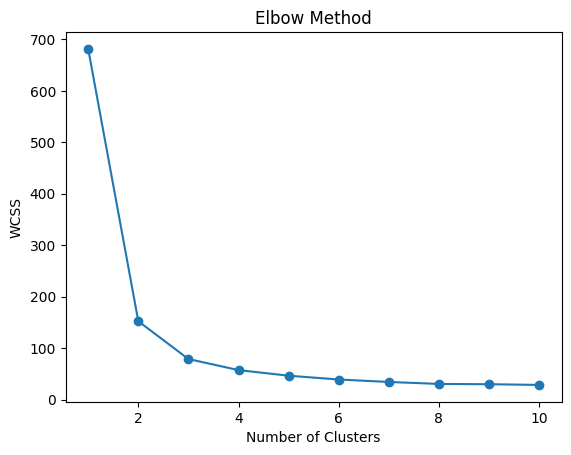

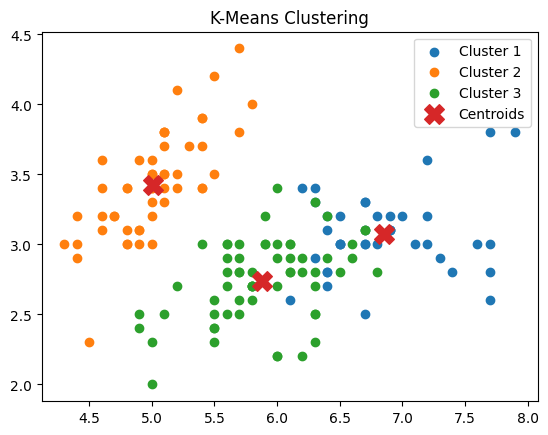

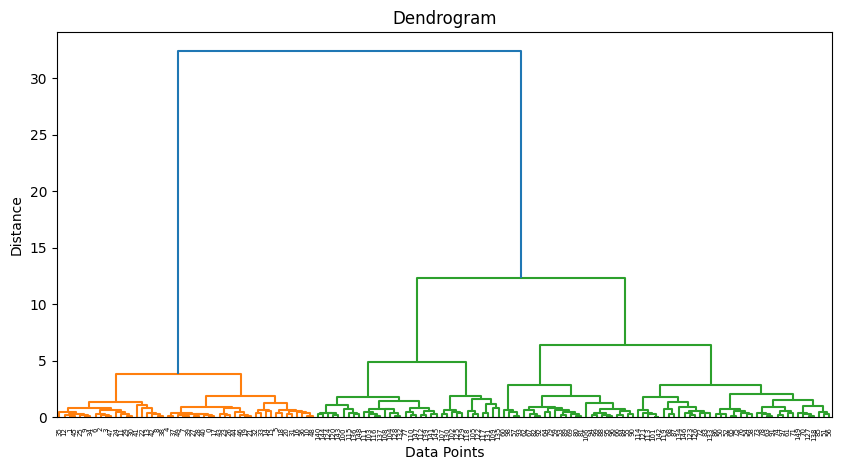

K-Means Clustering Done
Hierarchical Clustering Done


In [1]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================
# STEP 2: Load Dataset
# ==============================
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print(df.head())

# ==============================
# STEP 3: Select Features
# ==============================
X = df.iloc[:, :-1].values  # remove species

# ==============================
# STEP 4: Visualize Data (2D)
# ==============================
plt.scatter(X[:, 0], X[:, 1])
plt.title("Initial Data Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ==============================
# STEP 5: Elbow Method (K-Means)
# ==============================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ==============================
# STEP 6: Apply K-Means
# ==============================
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualization
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering")
plt.legend()
plt.show()

# ==============================
# STEP 7: Hierarchical Clustering
# ==============================
linked = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# ==============================
# STEP 8: Compare Results
# ==============================
print("K-Means Clustering Done")
print("Hierarchical Clustering Done")